# Exploratory Data Analysis (EDA) & Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

plt.style.use('default')
sns.set_theme(style="whitegrid")


In [2]:
df = pd.read_csv("Border_Crossing_Entry_Data.csv")
df.head()


,Port Name,State,Port Code,Border,Date,Measure,Value
0,Alcan,AK,3104,US-Canada Border,2/1/2020 00:00,Personal Vehicle Passengers,1414
1,Alcan,AK,3104,US-Canada Border,2/1/2020 00:00,Personal Vehicles,763
2,Alcan,AK,3104,US-Canada Border,2/1/2020 00:00,Truck Containers Empty,412
3,Alcan,AK,3104,US-Canada Border,2/1/2020 00:00,Truck Containers Full,122
4,Alcan,AK,3104,US-Canada Border,2/1/2020 00:00,Trucks,545


In [3]:
df.shape


(355511, 7)

In [4]:
df.dtypes

Port Name    object
State        object
Port Code     int64
Border       object
Date         object
Measure      object
Value         int64
dtype: object

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355511 entries, 0 to 355510
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Port Name  355511 non-null  object
 1   State      355511 non-null  object
 2   Port Code  355511 non-null  int64 
 3   Border     355511 non-null  object
 4   Date       355511 non-null  object
 5   Measure    355511 non-null  object
 6   Value      355511 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 19.0+ MB


In [6]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Port Name,355511,116,Eastport,5753,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,355511,15,ND,58290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Port Code,355511.0,NaN,NaN,NaN,2454.009921,1201.900231,101.0,2304.0,3013.0,3402.0,4105.0
Border,355511,2,US-Canada Border,272838,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,355511,290,7/1/2010 00:00,1356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Measure,355511,12,Personal Vehicles,31425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Value,355511.0,NaN,NaN,NaN,28447.5814,151880.707779,0.0,0.0,100.0,2597.5,4447374.0


In [7]:
df.nunique()

Port Name      116
State           15
Port Code      117
Border           2
Date           290
Measure         12
Value        54814
dtype: int64

In [8]:
df.isnull().sum() #Missing Value Analysis


Port Name    0
State        0
Port Code    0
Border       0
Date         0
Measure      0
Value        0
dtype: int64

In [9]:
(df.isnull().sum() / len(df)) * 100


Port Name    0.0
State        0.0
Port Code    0.0
Border       0.0
Date         0.0
Measure      0.0
Value        0.0
dtype: float64

In [10]:
df.duplicated().sum() #Duplicate Records Check 


np.int64(10)

In [11]:
df = df.drop_duplicates()
df.shape

(355501, 7)

In [12]:
# Date Feature Engineering

df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter


##  Univariate Analysis

### Distribution of Border Crossings (Value)

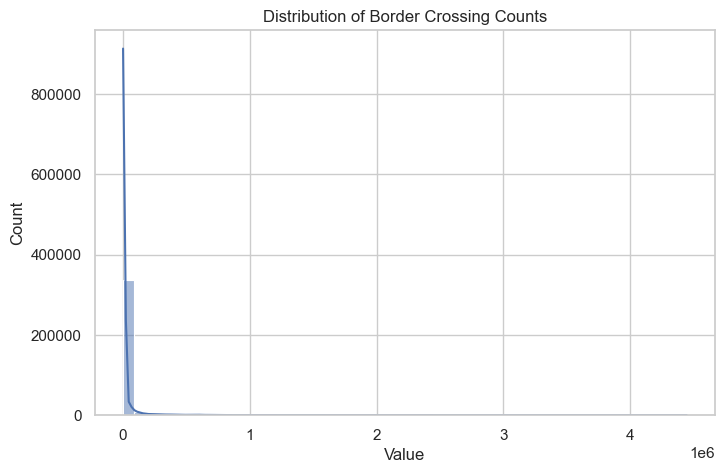

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['Value'], bins=50, kde=True)
plt.title("Distribution of Border Crossing Counts")
plt.show()


###  Border-wise Frequency

In [14]:
df['Border'].value_counts()


Border
US-Canada Border    272834
US-Mexico Border     82667
Name: count, dtype: int64

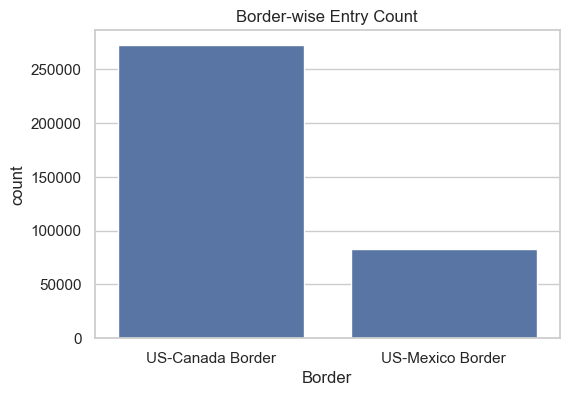

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Border', data=df)
plt.title("Border-wise Entry Count")
plt.show()


## Bivariate Analysis

### Border vs Value

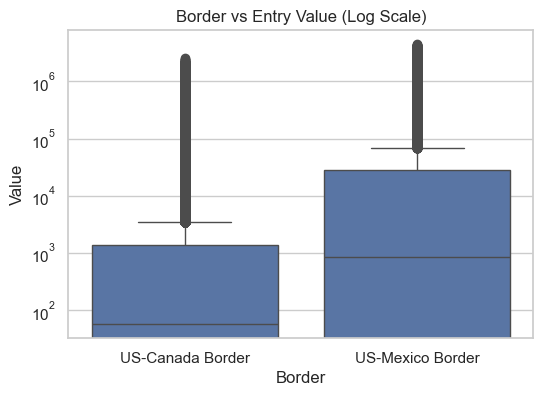

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Border', y='Value', data=df)
plt.yscale('log')
plt.title("Border vs Entry Value (Log Scale)")
plt.show()


###  Measure vs Value

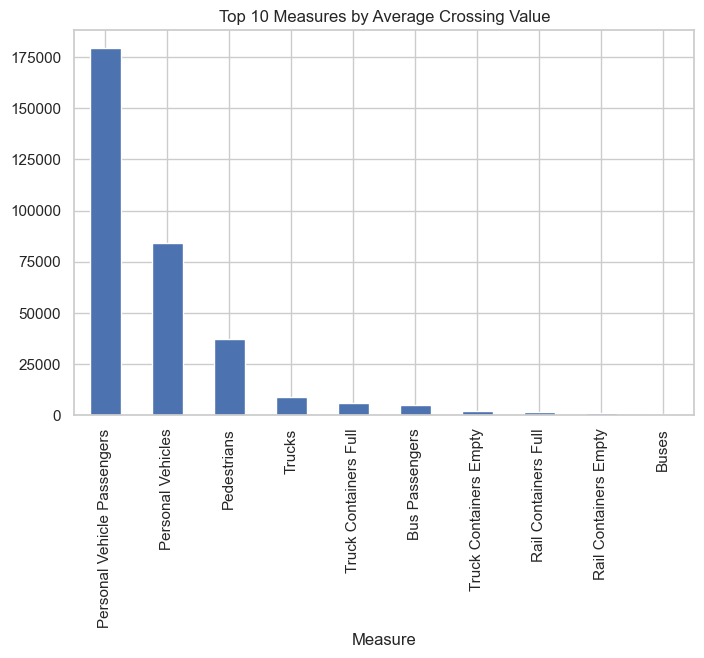

In [17]:
top_measures = df.groupby('Measure')['Value'].mean().sort_values(ascending=False).head(10)

top_measures.plot(kind='bar', figsize=(8,5))
plt.title("Top 10 Measures by Average Crossing Value")
plt.show()


## Time Series Trend Analysis 

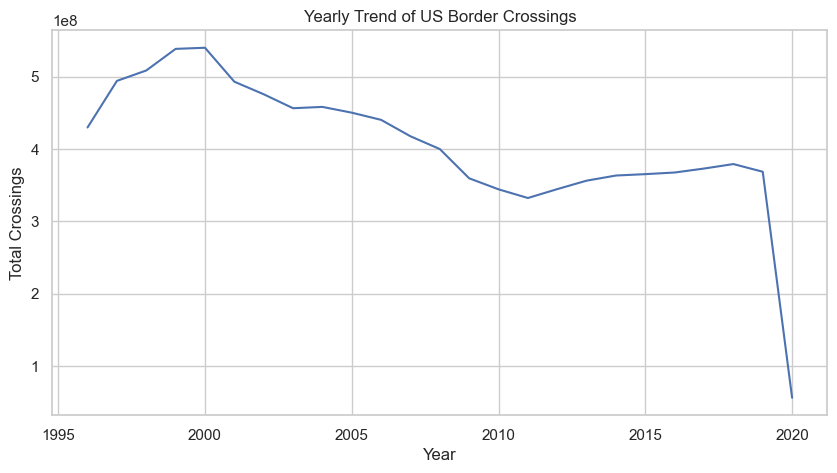

In [18]:
yearly_trend = df.groupby('Year')['Value'].sum()

plt.figure(figsize=(10,5))
yearly_trend.plot()
plt.title("Yearly Trend of US Border Crossings")
plt.ylabel("Total Crossings")
plt.show()


Number of Outliers: 65811


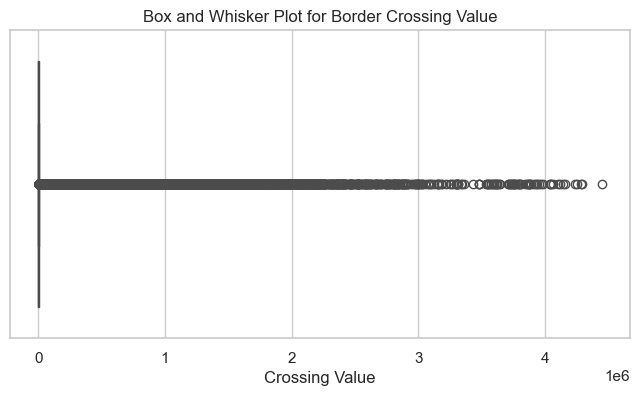

In [19]:
# Outlier Detection (IQR Method)
Q1 = df['Value'].quantile(0.25)
Q3 = df['Value'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Value'] < (Q1 - 1.5 * IQR)) | (df['Value'] > (Q3 + 1.5 * IQR))]
print("Number of Outliers:", outliers.shape[0])

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Value'])
plt.title('Box and Whisker Plot for Border Crossing Value')
plt.xlabel('Crossing Value')
plt.show()

In [20]:
# Encoding Categorical Variables
cat_cols = ['Border', 'State', 'Port Name', 'Measure']

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])


##  Feature Scaling

In [21]:
# Step 1: Create target using cut()
df['Crossing_Level'] = pd.cut(
    df['Value'],
    bins=[-1, 1000, 100000, df['Value'].max()],
    labels=['Low', 'Medium', 'High']
)


In [22]:

columns_to_scale = ['Value', 'Year', 'Month', 'Quarter']

scaler = StandardScaler()
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

In [23]:
# Step 2: Encode target
df['Crossing_Level'] = df['Crossing_Level'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})


In [24]:
#Step 3: Verify
df['Crossing_Level'].value_counts()


Crossing_Level
0    239123
1     98224
2     18154
Name: count, dtype: int64

## Final Feature Selection

In [25]:
X = df.drop([
    'Date',              
    'Crossing_Level'     
], axis=1)

y = df['Crossing_Level']


In [26]:
X.head()


,Port Name,State,Port Code,Border,Measure,Value,Year,Month,Quarter
0,0,0,3104,0,3,-0.177970,1.940064,-1.289849,-1.32904
1,0,0,3104,0,4,-0.182256,1.940064,-1.289849,-1.32904
2,0,0,3104,0,9,-0.184567,1.940064,-1.289849,-1.32904
3,0,0,3104,0,10,-0.186477,1.940064,-1.289849,-1.32904
4,0,0,3104,0,11,-0.183692,1.940064,-1.289849,-1.32904


## Class balancing

In [27]:
print("Original Dataset Size:")
print(y.value_counts())

# Apply SMOTE + Tomek Links
balance = SMOTETomek(random_state=42)
X_resampled, y_resampled = balance.fit_resample(X, y)

print("\nResampled Dataset Size:")
print(y_resampled.value_counts())

Original Dataset Size:
Crossing_Level
0    239123
1     98224
2     18154
Name: count, dtype: int64

Resampled Dataset Size:
Crossing_Level
2    239092
0    238005
1    237974
Name: count, dtype: int64


## Train–Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


##  FINAL VERIFICATION

In [29]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nClass distribution in y_train:")
print(y_train.value_counts())

print("\nClass distribution in y_test:")
print(y_test.value_counts())


X_train shape: (248850, 9)
X_test shape: (106651, 9)

Class distribution in y_train:
Crossing_Level
0    167386
1     68756
2     12708
Name: count, dtype: int64

Class distribution in y_test:
Crossing_Level
0    71737
1    29468
2     5446
Name: count, dtype: int64


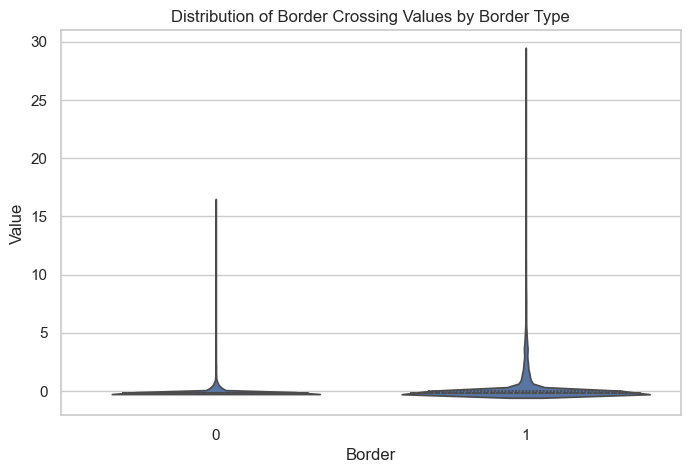

In [30]:
plt.figure(figsize=(8,5))
sns.violinplot(
    x='Border',
    y='Value',
    data=df,
    inner='quartile'
)
plt.title("Distribution of Border Crossing Values by Border Type")
plt.show()


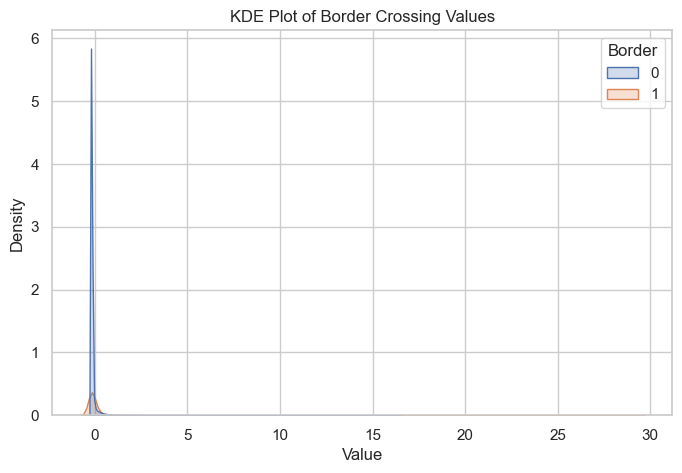

In [31]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df,
    x='Value',
    hue='Border',
    fill=True
)
plt.title("KDE Plot of Border Crossing Values")
plt.show()


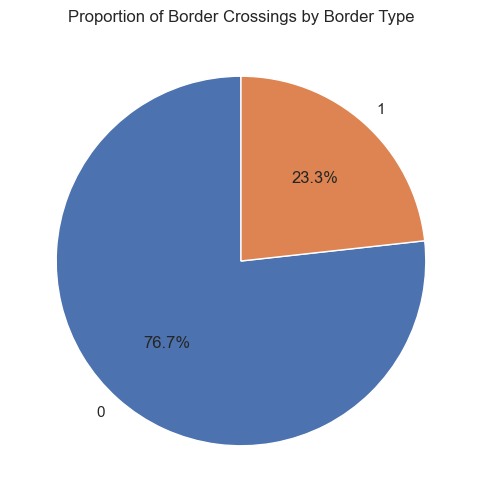

In [32]:
border_counts = df['Border'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    border_counts,
    labels=border_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Proportion of Border Crossings by Border Type")
plt.show()


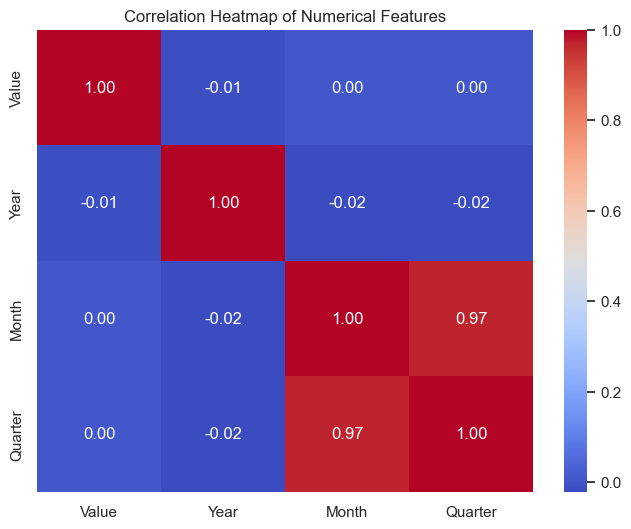

In [33]:
plt.figure(figsize=(8,6))
corr = df[['Value', 'Year', 'Month', 'Quarter']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


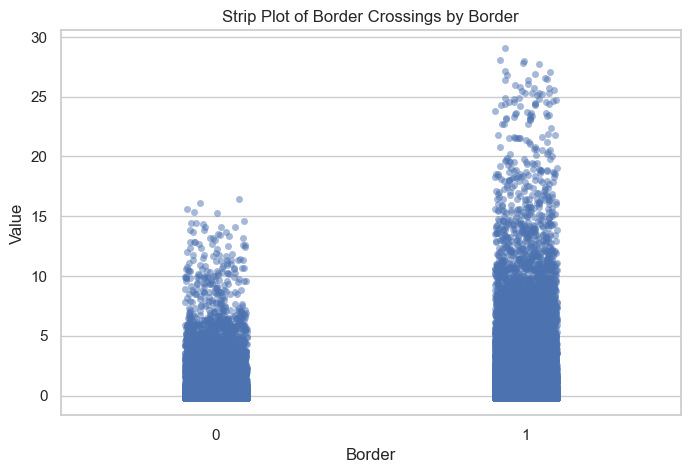

In [34]:
plt.figure(figsize=(8,5))
sns.stripplot(
    x='Border',
    y='Value',
    data=df,
    jitter=True,
    alpha=0.5
)
plt.title("Strip Plot of Border Crossings by Border")
plt.show()


## ALGORITHM

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)


In [36]:
# Define Base Models with Hyperparameters
lr = LogisticRegression(
    max_iter=5000,
    solver='lbfgs',
    n_jobs=-1
)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
svm = LinearSVC(max_iter=3000)




In [37]:
# Train Individual Models (For Comparison)
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Linear SVM": svm
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name} Accuracy: {acc:.4f}")


Logistic Regression Accuracy: 0.8853
Random Forest Accuracy: 1.0000
Linear SVM Accuracy: 0.8227


In [38]:
# Apply Voting Classifier (Soft Voting)
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('svm', svm)
    ],
    voting='hard'
)

voting_clf.fit(X_train, y_train)


,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [39]:
#  Model Evaluation

In [40]:
# accuracy
y_pred = voting_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Voting Classifier Accuracy:", accuracy)


Voting Classifier Accuracy: 0.8891243401374577


In [41]:
#classification report 
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.86      1.00      0.93     71737
           1       1.00      0.60      0.75     29468
           2       0.96      1.00      0.98      5446

    accuracy                           0.89    106651
   macro avg       0.94      0.87      0.88    106651
weighted avg       0.90      0.89      0.88    106651



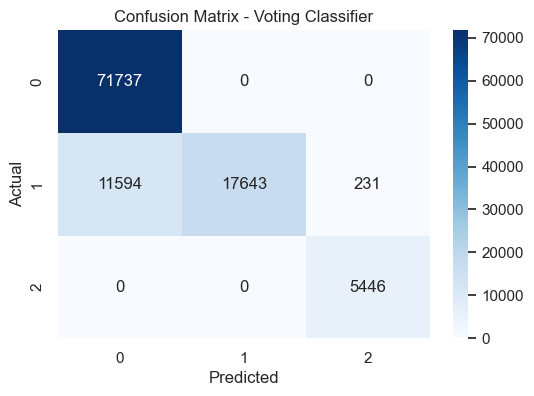

In [42]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Voting Classifier")
plt.show()


In [44]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix
)

y_pred = voting_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)


Accuracy: 0.8891243401374577
Precision: 0.9043374624283628
Recall: 0.8891243401374577
F1 Score: 0.8792957326773194
Confusion Matrix:
 [[71737     0     0]
 [11594 17643   231]
 [    0     0  5446]]


In [45]:
# Model Comparison Summary Table
results = []

for name, model in models.items():
    preds = model.predict(X_test)
    results.append([
        name,
        accuracy_score(y_test, preds)
    ])

results.append(["Voting Classifier", accuracy])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy"]
)

results_df


,Model,Accuracy
0,Logistic Regression,0.885336
1,Random Forest,1.000000
2,Linear SVM,0.822655
3,Voting Classifier,0.889124
